In [1]:
# ============================================================
# CELL 1 — IMPORTS & LOAD DATA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# ── Plot styling ────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#0f0f0f',
    'axes.facecolor':    '#1a1a2e',
    'axes.edgecolor':    '#444466',
    'axes.labelcolor':   '#e0e0e0',
    'axes.titlecolor':   '#ffffff',
    'axes.titlesize':    14,
    'axes.labelsize':    11,
    'xtick.color':       '#aaaaaa',
    'ytick.color':       '#aaaaaa',
    'text.color':        '#e0e0e0',
    'grid.color':        '#2a2a4a',
    'grid.linestyle':    '--',
    'grid.alpha':        0.5,
    'legend.facecolor':  '#1a1a2e',
    'legend.edgecolor':  '#444466',
    'font.family':       'DejaVu Sans',
})

# Archetype colour palette — used consistently across all charts
ARCHETYPE_COLORS = {
    'star':       '#00d4aa',
    'stable':     '#4a9eff',
    'new':        '#f7b731',
    'struggling': '#ff6b6b',
    'critical':   '#ff2d55',
}

TIER_COLORS = {
    1: '#00d4aa',
    2: '#4a9eff',
    3: '#f7b731',
}

# ── Load data ───────────────────────────────────────────────
raw_path       = r'D:\Projects\End-to-end projects\12. Franchise Intelligence System\Data\Raw'
processed_path = r'D:\Projects\End-to-end projects\12. Franchise Intelligence System\Data\Processed'

outlet_master      = pd.read_csv(f'{raw_path}\\outlet_master.csv')
daily_transactions = pd.read_csv(f'{raw_path}\\daily_transactions.csv',
                                  parse_dates=['transaction_date'])
monthly_perf       = pd.read_csv(f'{raw_path}\\monthly_performance.csv')
staff_df           = pd.read_csv(f'{raw_path}\\staff_records.csv')
reviews_df         = pd.read_csv(f'{raw_path}\\customer_reviews.csv',
                                  parse_dates=['review_date'])
outlet_scores      = pd.read_csv(f'{processed_path}\\outlet_scores.csv')

print("✅ All datasets loaded")
print(f"  outlet_master      : {outlet_master.shape}")
print(f"  daily_transactions : {daily_transactions.shape}")
print(f"  monthly_perf       : {monthly_perf.shape}")
print(f"  staff_df           : {staff_df.shape}")
print(f"  reviews_df         : {reviews_df.shape}")
print(f"  outlet_scores      : {outlet_scores.shape}")

✅ All datasets loaded
  outlet_master      : (85, 12)
  daily_transactions : (681949, 32)
  monthly_perf       : (1530, 39)
  staff_df           : (1530, 11)
  reviews_df         : (28585, 11)
  outlet_scores      : (85, 29)


In [3]:
# ============================================================
# CELL 1 — IMPORTS & STYLE CONFIGURATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# ── Global Plot Style ───────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':    '#0F1117',
    'axes.facecolor':      '#1A1D27',
    'axes.edgecolor':      '#2E3250',
    'axes.labelcolor':     '#E0E0E0',
    'axes.titlecolor':     '#FFFFFF',
    'axes.titlesize':      14,
    'axes.labelsize':      11,
    'xtick.color':         '#A0A0A0',
    'ytick.color':         '#A0A0A0',
    'xtick.labelsize':     9,
    'ytick.labelsize':     9,
    'text.color':          '#E0E0E0',
    'grid.color':          '#2E3250',
    'grid.linestyle':      '--',
    'grid.alpha':          0.5,
    'legend.facecolor':    '#1A1D27',
    'legend.edgecolor':    '#2E3250',
    'legend.fontsize':     9,
    'figure.titlesize':    16,
    'figure.titleweight':  'bold',
})

# Brand colour palette
COLORS = {
    'star':       '#00D4AA',
    'stable':     '#4A90D9',
    'new':        '#F5A623',
    'struggling': '#E8724A',
    'critical':   '#E84A4A',
}

TIER_COLORS  = ['#00D4AA', '#4A90D9', '#F5A623']
CHART_COLORS = ['#00D4AA','#4A90D9','#F5A623','#E8724A','#E84A4A',
                '#9B59B6','#1ABC9C','#3498DB','#E74C3C','#F39C12']

# Output path for saving charts
CHART_PATH = r'D:\Projects\End-to-end projects\12. Franchise Intelligence System\Reports'

import plotly
print("✅ Imports and style configuration complete")
print(f"Matplotlib version : {plt.matplotlib.__version__}")
print(f"Seaborn version    : {sns.__version__}")
print(f"Plotly version     : {plotly.__version__}")

✅ Imports and style configuration complete
Matplotlib version : 3.10.0
Seaborn version    : 0.13.2
Plotly version     : 6.6.0


In [4]:
# ============================================================
# CELL 2 — LOAD ALL DATASETS
# ============================================================

raw_path       = r'D:\Projects\End-to-end projects\12. Franchise Intelligence System\Data\Raw'
processed_path = r'D:\Projects\End-to-end projects\12. Franchise Intelligence System\Data\Processed'

outlet_master      = pd.read_csv(f'{raw_path}\\outlet_master.csv')
daily_transactions = pd.read_csv(f'{raw_path}\\daily_transactions.csv')
monthly_perf       = pd.read_csv(f'{raw_path}\\monthly_performance.csv')
staff_df           = pd.read_csv(f'{raw_path}\\staff_records.csv')
reviews_df         = pd.read_csv(f'{raw_path}\\customer_reviews.csv')
outlet_scores      = pd.read_csv(f'{processed_path}\\outlet_scores.csv')

# Parse dates
daily_transactions['transaction_date'] = pd.to_datetime(daily_transactions['transaction_date'])
monthly_perf['month']                  = pd.to_datetime(monthly_perf['month'])
reviews_df['review_date']              = pd.to_datetime(reviews_df['review_date'])

print("✅ All datasets loaded")
print(f"\n  outlet_master      : {outlet_master.shape}")
print(f"  daily_transactions : {daily_transactions.shape}")
print(f"  monthly_perf       : {monthly_perf.shape}")
print(f"  staff_df           : {staff_df.shape}")
print(f"  reviews_df         : {reviews_df.shape}")
print(f"  outlet_scores      : {outlet_scores.shape}")

✅ All datasets loaded

  outlet_master      : (85, 12)
  daily_transactions : (681949, 32)
  monthly_perf       : (1530, 39)
  staff_df           : (1530, 11)
  reviews_df         : (28585, 11)
  outlet_scores      : (85, 29)


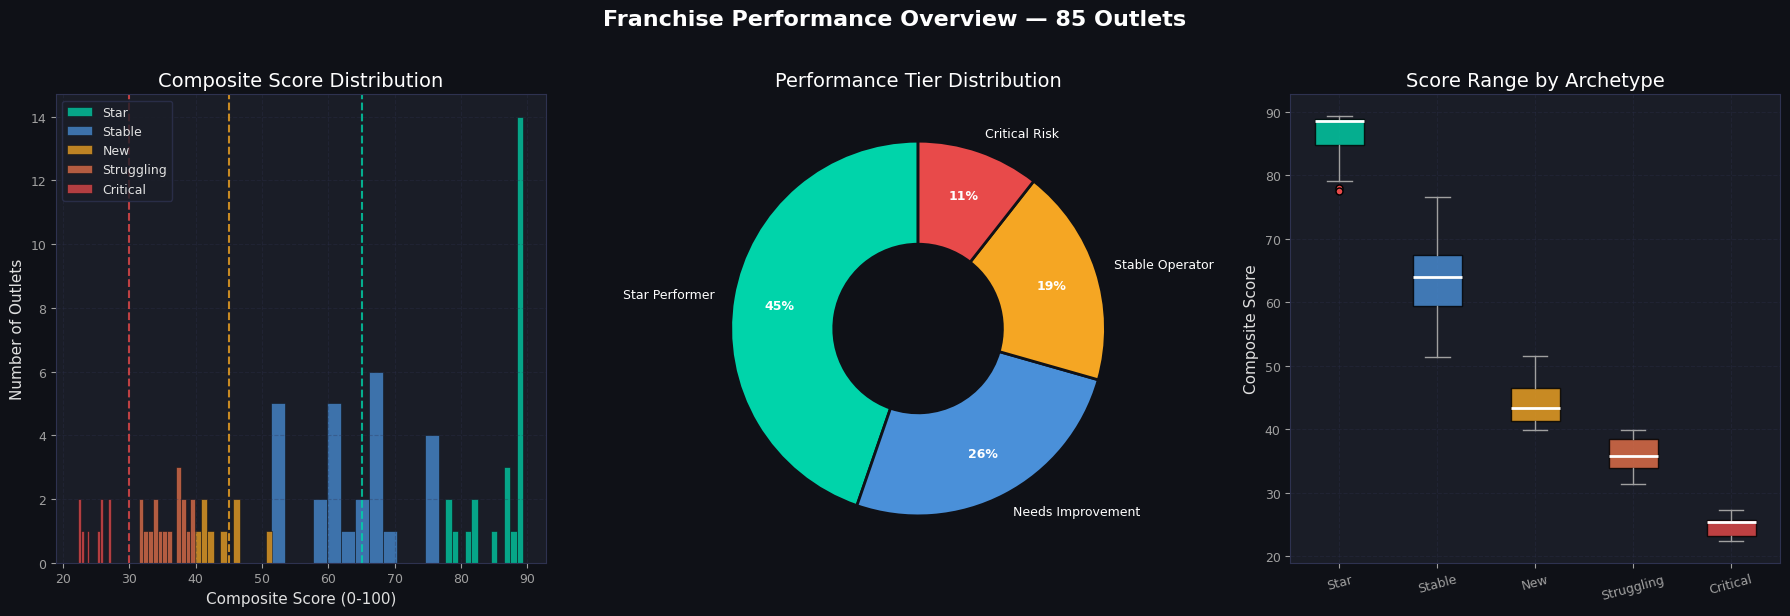

✅ Chart 1 saved


In [5]:
# ============================================================
# CHART 1 — FRANCHISE PERFORMANCE SCORE DISTRIBUTION
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Franchise Performance Overview — 85 Outlets', 
             fontsize=16, fontweight='bold', color='white', y=1.02)

# ── Plot 1: Composite Score Distribution ───────────────────
ax1 = axes[0]
archetype_order = ['star', 'stable', 'new', 'struggling', 'critical']
for archetype in archetype_order:
    data = outlet_scores[outlet_scores['archetype'] == archetype]['composite_score']
    ax1.hist(data, bins=12, alpha=0.75, 
             color=COLORS[archetype], label=archetype.title(),
             edgecolor='#0F1117', linewidth=0.5)

ax1.axvline(x=65, color='#00D4AA', linestyle='--', linewidth=1.5, alpha=0.8)
ax1.axvline(x=45, color='#F5A623', linestyle='--', linewidth=1.5, alpha=0.8)
ax1.axvline(x=30, color='#E84A4A', linestyle='--', linewidth=1.5, alpha=0.8)
ax1.set_title('Composite Score Distribution', color='white')
ax1.set_xlabel('Composite Score (0-100)')
ax1.set_ylabel('Number of Outlets')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# ── Plot 2: Performance Tier Donut Chart ───────────────────
ax2 = axes[1]
tier_counts = outlet_scores['performance_tier'].value_counts()
tier_labels = [t.split('—')[1].strip() for t in tier_counts.index]
tier_colors = ['#00D4AA', '#4A90D9', '#F5A623', '#E84A4A']
wedges, texts, autotexts = ax2.pie(
    tier_counts.values,
    labels=tier_labels,
    colors=tier_colors[:len(tier_counts)],
    autopct='%1.0f%%',
    pctdistance=0.75,
    startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='#0F1117', linewidth=2)
)
for text in texts:
    text.set_color('white')
    text.set_fontsize(9)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(9)
    autotext.set_fontweight('bold')
ax2.set_title('Performance Tier Distribution', color='white')

# ── Plot 3: Composite Score by Archetype Boxplot ──────────
ax3 = axes[2]
archetype_data = [
    outlet_scores[outlet_scores['archetype'] == a]['composite_score'].values
    for a in archetype_order
]
bp = ax3.boxplot(archetype_data,
                 patch_artist=True,
                 medianprops=dict(color='white', linewidth=2),
                 whiskerprops=dict(color='#A0A0A0'),
                 capprops=dict(color='#A0A0A0'),
                 flierprops=dict(marker='o', markerfacecolor='#E84A4A', 
                                markersize=5))
for patch, archetype in zip(bp['boxes'], archetype_order):
    patch.set_facecolor(COLORS[archetype])
    patch.set_alpha(0.8)

ax3.set_xticklabels([a.title() for a in archetype_order], rotation=15)
ax3.set_title('Score Range by Archetype', color='white')
ax3.set_ylabel('Composite Score')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{CHART_PATH}\\chart_01_performance_overview.png',
            dpi=150, bbox_inches='tight',
            facecolor='#0F1117')
plt.show()
print("✅ Chart 1 saved")

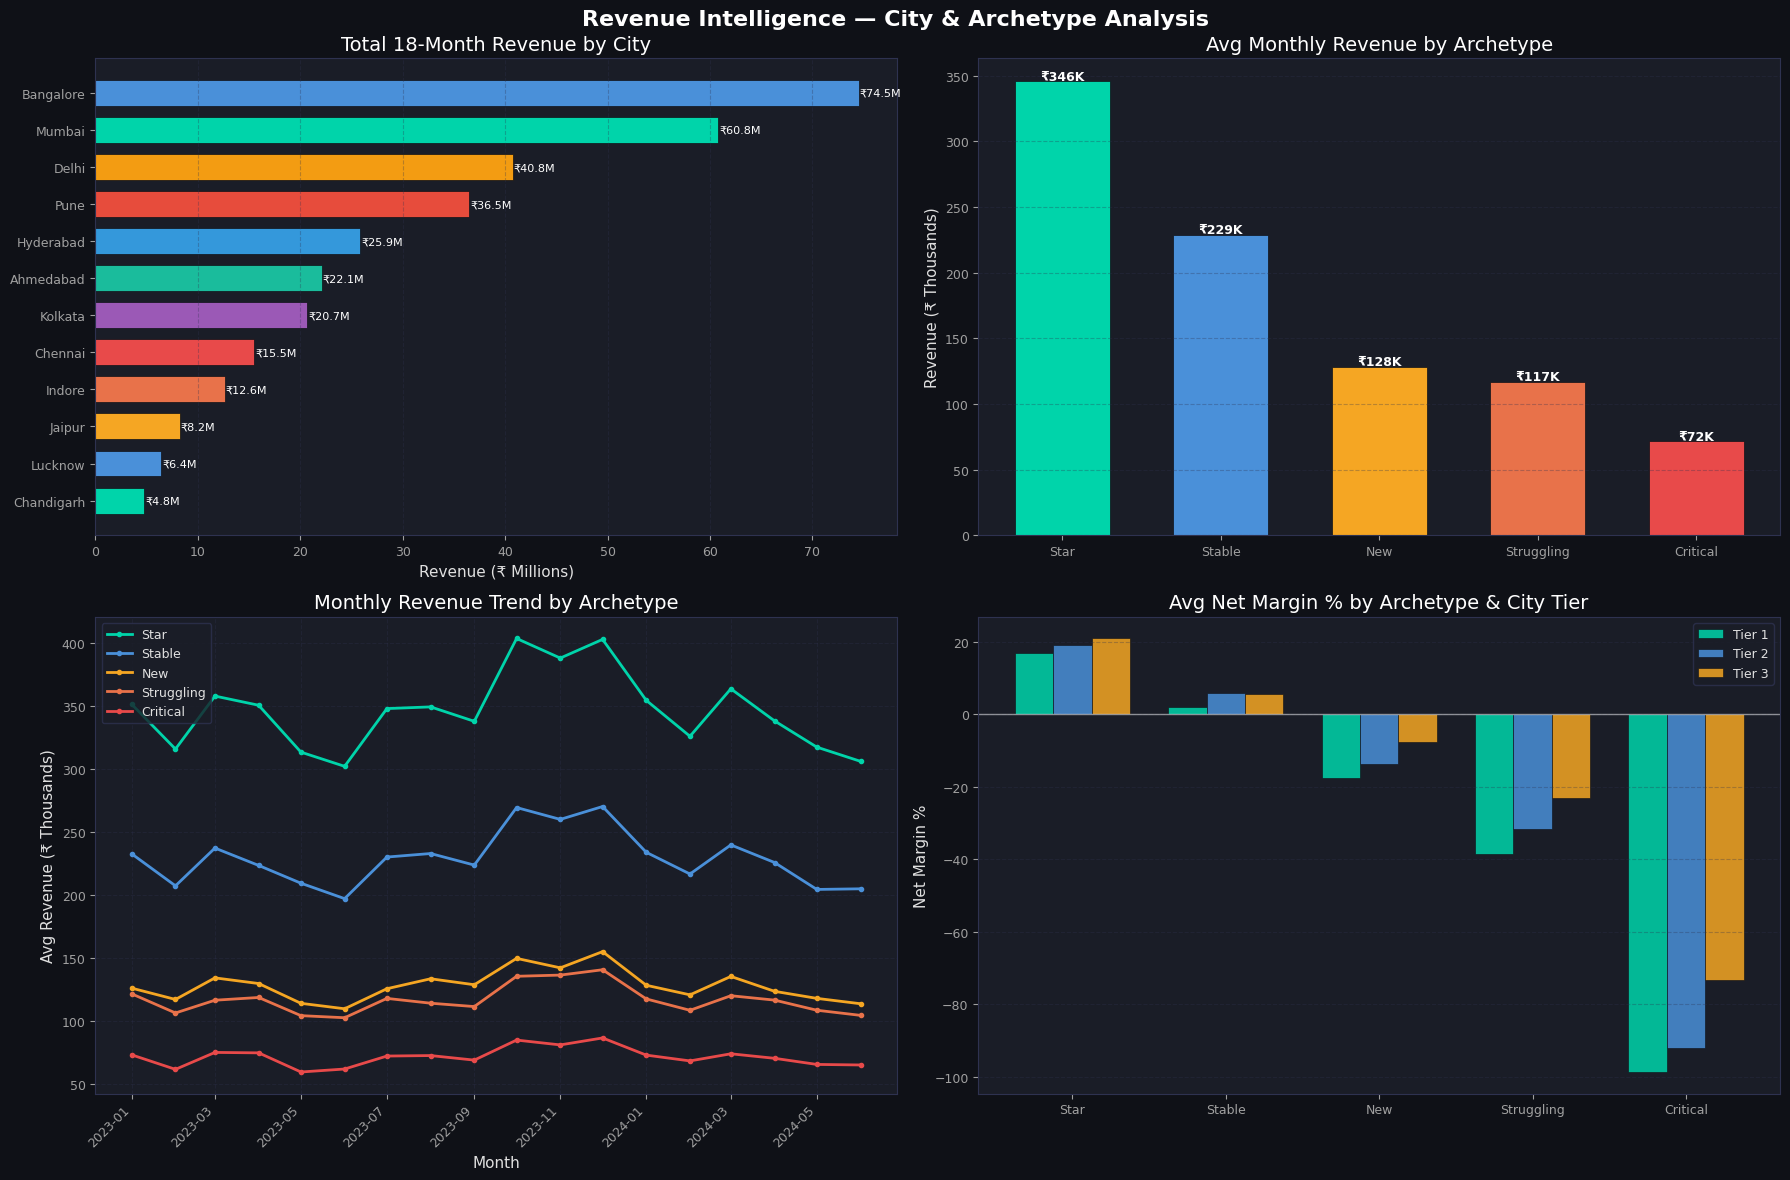

✅ Chart 2 saved


In [6]:
# ============================================================
# CHART 2 — REVENUE ANALYSIS BY CITY & ARCHETYPE
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Revenue Intelligence — City & Archetype Analysis',
             fontsize=16, fontweight='bold', color='white')

# ── Plot 1: Total Revenue by City ──────────────────────────
ax1 = axes[0, 0]
city_revenue = monthly_perf.groupby('city')['revenue'].sum().sort_values(ascending=True)
bars = ax1.barh(city_revenue.index, city_revenue.values / 1e6,
                color=CHART_COLORS[:len(city_revenue)],
                edgecolor='#0F1117', linewidth=0.5, height=0.7)
for bar, val in zip(bars, city_revenue.values / 1e6):
    ax1.text(val + 0.1, bar.get_y() + bar.get_height()/2,
             f'₹{val:.1f}M', va='center', color='white', fontsize=8)
ax1.set_title('Total 18-Month Revenue by City', color='white')
ax1.set_xlabel('Revenue (₹ Millions)')
ax1.grid(True, alpha=0.3, axis='x')

# ── Plot 2: Avg Monthly Revenue by Archetype ───────────────
ax2 = axes[0, 1]
arch_revenue = monthly_perf.groupby('archetype')['revenue'].mean()
arch_revenue = arch_revenue.reindex(archetype_order)
bars = ax2.bar(arch_revenue.index,
               arch_revenue.values / 1000,
               color=[COLORS[a] for a in arch_revenue.index],
               edgecolor='#0F1117', linewidth=0.5, width=0.6)
for bar, val in zip(bars, arch_revenue.values / 1000):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'₹{val:.0f}K', ha='center', color='white', fontsize=9,
             fontweight='bold')
ax2.set_title('Avg Monthly Revenue by Archetype', color='white')
ax2.set_ylabel('Revenue (₹ Thousands)')
ax2.set_xticklabels([a.title() for a in arch_revenue.index])
ax2.grid(True, alpha=0.3, axis='y')

# ── Plot 3: Monthly Revenue Trend by Archetype ─────────────
ax3 = axes[1, 0]
for archetype in archetype_order:
    trend = monthly_perf[monthly_perf['archetype'] == archetype].groupby(
        'month')['revenue'].mean()
    ax3.plot(trend.index, trend.values / 1000,
             color=COLORS[archetype], linewidth=2,
             label=archetype.title(), marker='o', markersize=3)

ax3.set_title('Monthly Revenue Trend by Archetype', color='white')
ax3.set_ylabel('Avg Revenue (₹ Thousands)')
ax3.set_xlabel('Month')
ax3.legend(loc='upper left')
ax3.grid(True, alpha=0.3)
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

# ── Plot 4: Net Margin % by Archetype & City Tier ──────────
ax4 = axes[1, 1]
margin_data = monthly_perf.groupby(['archetype', 'tier'])['net_margin_pct'].mean().unstack()
margin_data = margin_data.reindex(archetype_order)
x     = np.arange(len(margin_data.index))
width = 0.25
for i, tier in enumerate(margin_data.columns):
    bars = ax4.bar(x + i * width, margin_data[tier],
                   width=width, label=f'Tier {tier}',
                   color=TIER_COLORS[i], alpha=0.85,
                   edgecolor='#0F1117', linewidth=0.5)
ax4.axhline(y=0, color='white', linewidth=1, linestyle='-', alpha=0.5)
ax4.set_title('Avg Net Margin % by Archetype & City Tier', color='white')
ax4.set_ylabel('Net Margin %')
ax4.set_xticks(x + width)
ax4.set_xticklabels([a.title() for a in margin_data.index])
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{CHART_PATH}\\chart_02_revenue_analysis.png',
            dpi=150, bbox_inches='tight',
            facecolor='#0F1117')
plt.show()
print("✅ Chart 2 saved")

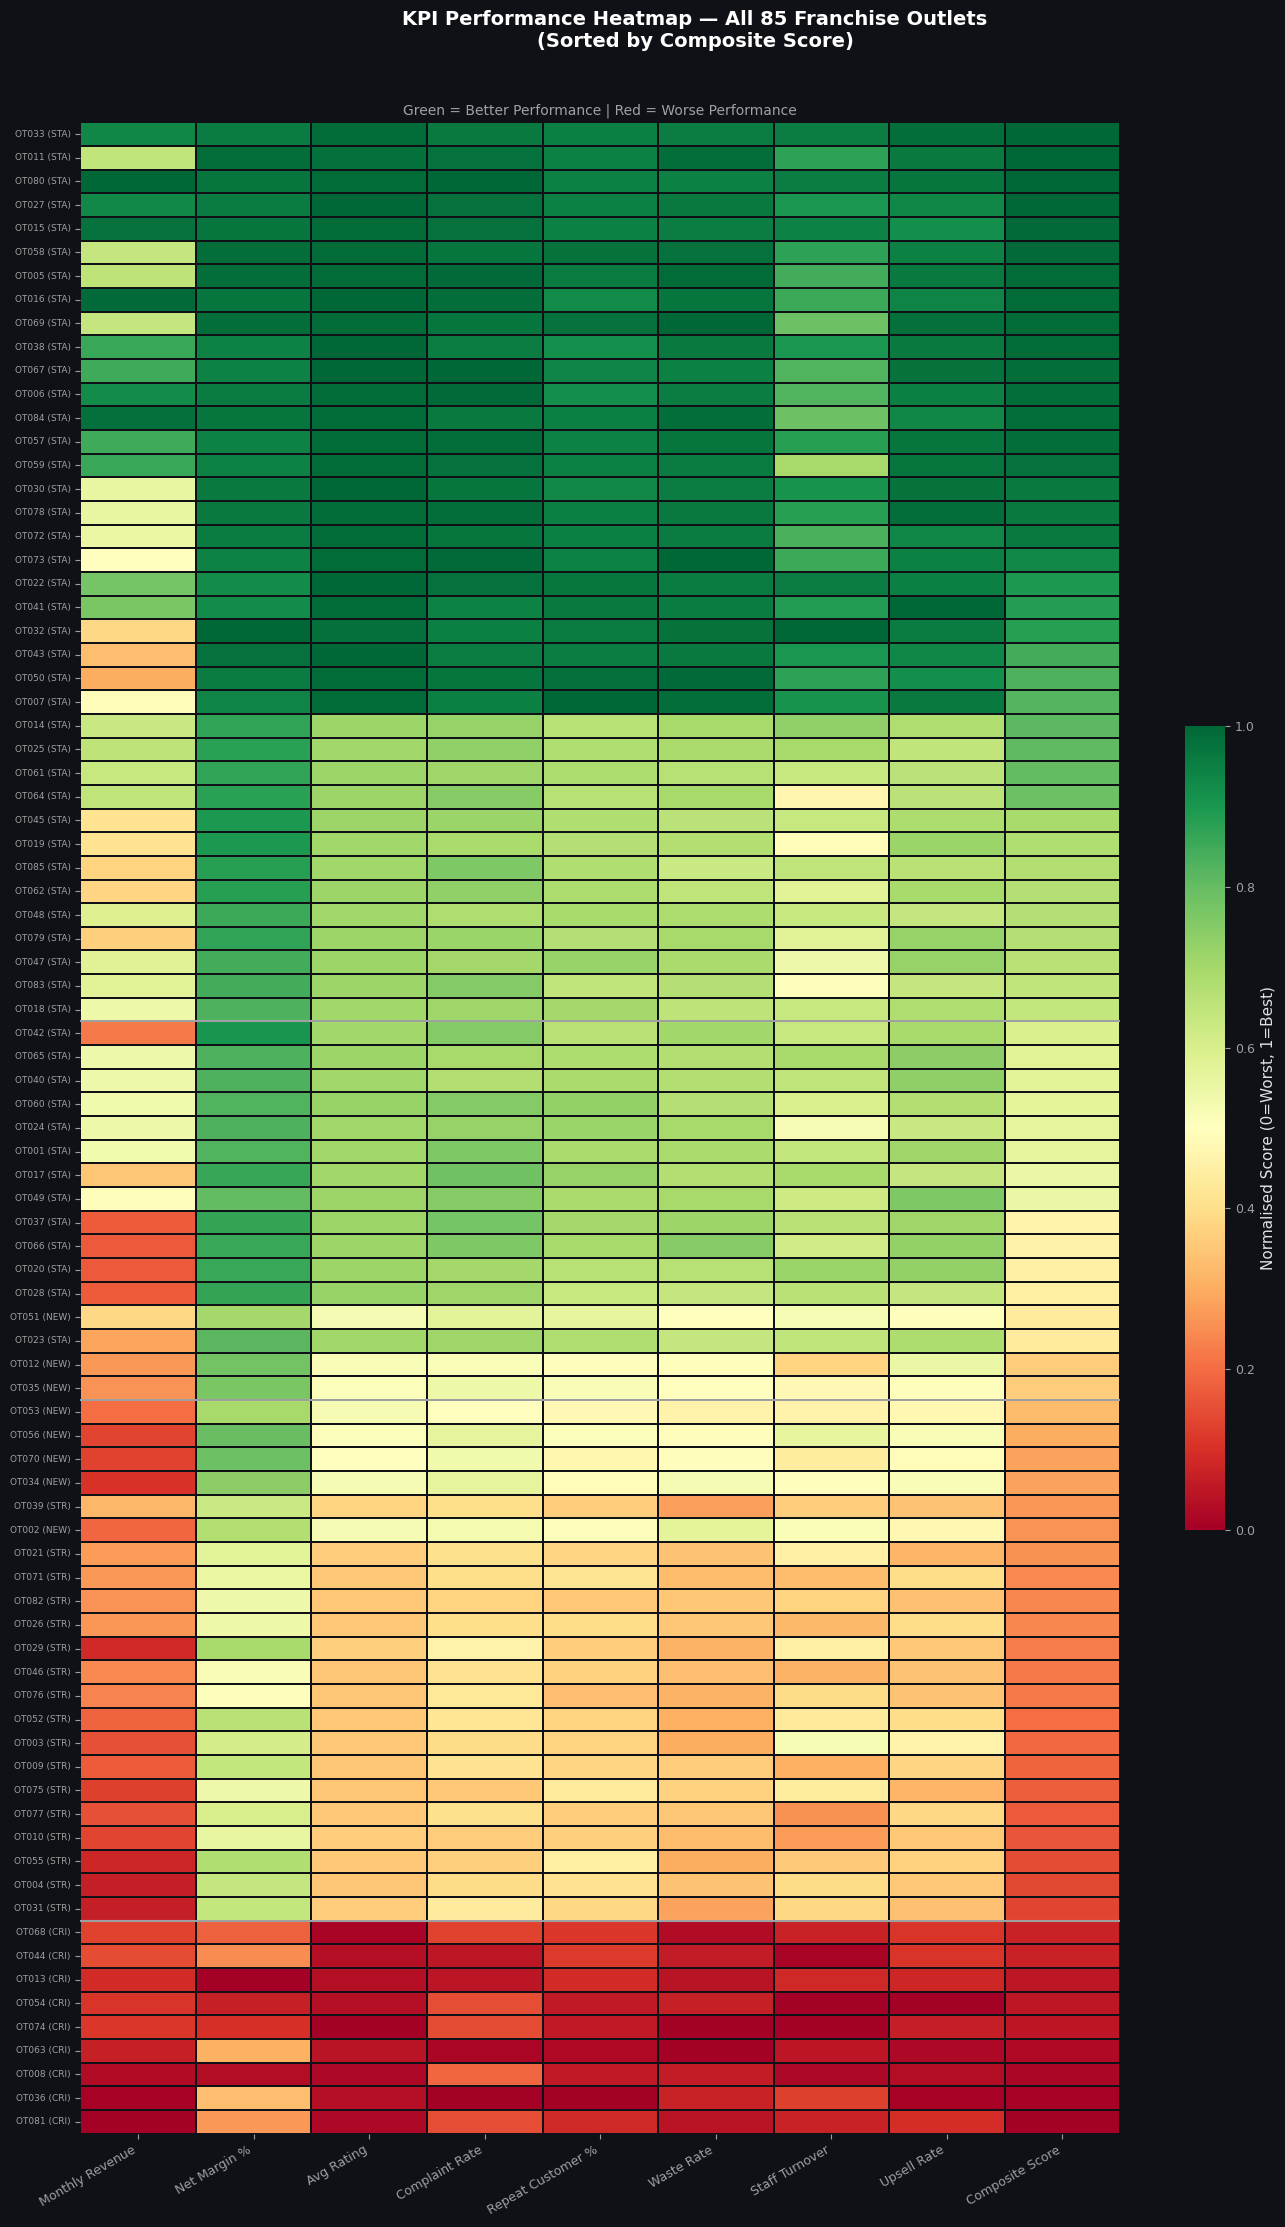

✅ Chart 3 saved


In [7]:
# ============================================================
# CHART 3 — KPI HEATMAP — ALL 85 OUTLETS
# ============================================================

# Select key KPIs for heatmap
kpi_cols = [
    'avg_monthly_revenue', 'avg_net_margin_pct',
    'avg_rating',          'avg_complaint_rate',
    'avg_repeat_pct',      'avg_waste_rate',
    'avg_staff_turnover',  'avg_upsell_rate',
    'composite_score'
]

kpi_labels = [
    'Monthly Revenue', 'Net Margin %',
    'Avg Rating',      'Complaint Rate',
    'Repeat Customer %', 'Waste Rate',
    'Staff Turnover',  'Upsell Rate',
    'Composite Score'
]

# Normalize each KPI to 0-1 for heatmap
heatmap_data = outlet_scores[kpi_cols].copy()

# Invert metrics where lower is better
invert_cols = ['avg_complaint_rate', 'avg_waste_rate', 'avg_staff_turnover']
for col in invert_cols:
    heatmap_data[col] = heatmap_data[col].max() - heatmap_data[col]

# Normalize
for col in kpi_cols:
    col_min = heatmap_data[col].min()
    col_max = heatmap_data[col].max()
    if col_max > col_min:
        heatmap_data[col] = (heatmap_data[col] - col_min) / (col_max - col_min)

# Sort by composite score
heatmap_data.index = outlet_scores['outlet_id'] + ' (' + outlet_scores['archetype'].str[:3].str.upper() + ')'
heatmap_data = heatmap_data.sort_values('composite_score', ascending=False)

fig, ax = plt.subplots(figsize=(14, 22))
fig.suptitle('KPI Performance Heatmap — All 85 Franchise Outlets\n(Sorted by Composite Score)',
             fontsize=14, fontweight='bold', color='white', y=1.01)

sns.heatmap(
    heatmap_data,
    ax=ax,
    cmap='RdYlGn',
    linewidths=0.3,
    linecolor='#0F1117',
    annot=False,
    cbar_kws={'label': 'Normalised Score (0=Worst, 1=Best)',
              'shrink': 0.4}
)

ax.set_xticklabels(kpi_labels, rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=6.5)
ax.set_title('Green = Better Performance | Red = Worse Performance',
             color='#A0A0A0', fontsize=10)

# Add tier separator lines
tier_breaks = [
    outlet_scores.sort_values('composite_score', ascending=False)['performance_tier'].tolist().index(t)
    for t in ['TIER 2 — Stable Operator', 'TIER 3 — Needs Improvement', 'TIER 4 — Critical Risk']
    if t in outlet_scores['performance_tier'].values
]
for break_point in set(tier_breaks):
    ax.axhline(y=break_point, color='white', linewidth=1.5, alpha=0.6)

plt.tight_layout()
plt.savefig(f'{CHART_PATH}\\chart_03_kpi_heatmap.png',
            dpi=150, bbox_inches='tight',
            facecolor='#0F1117')
plt.show()
print("✅ Chart 3 saved")

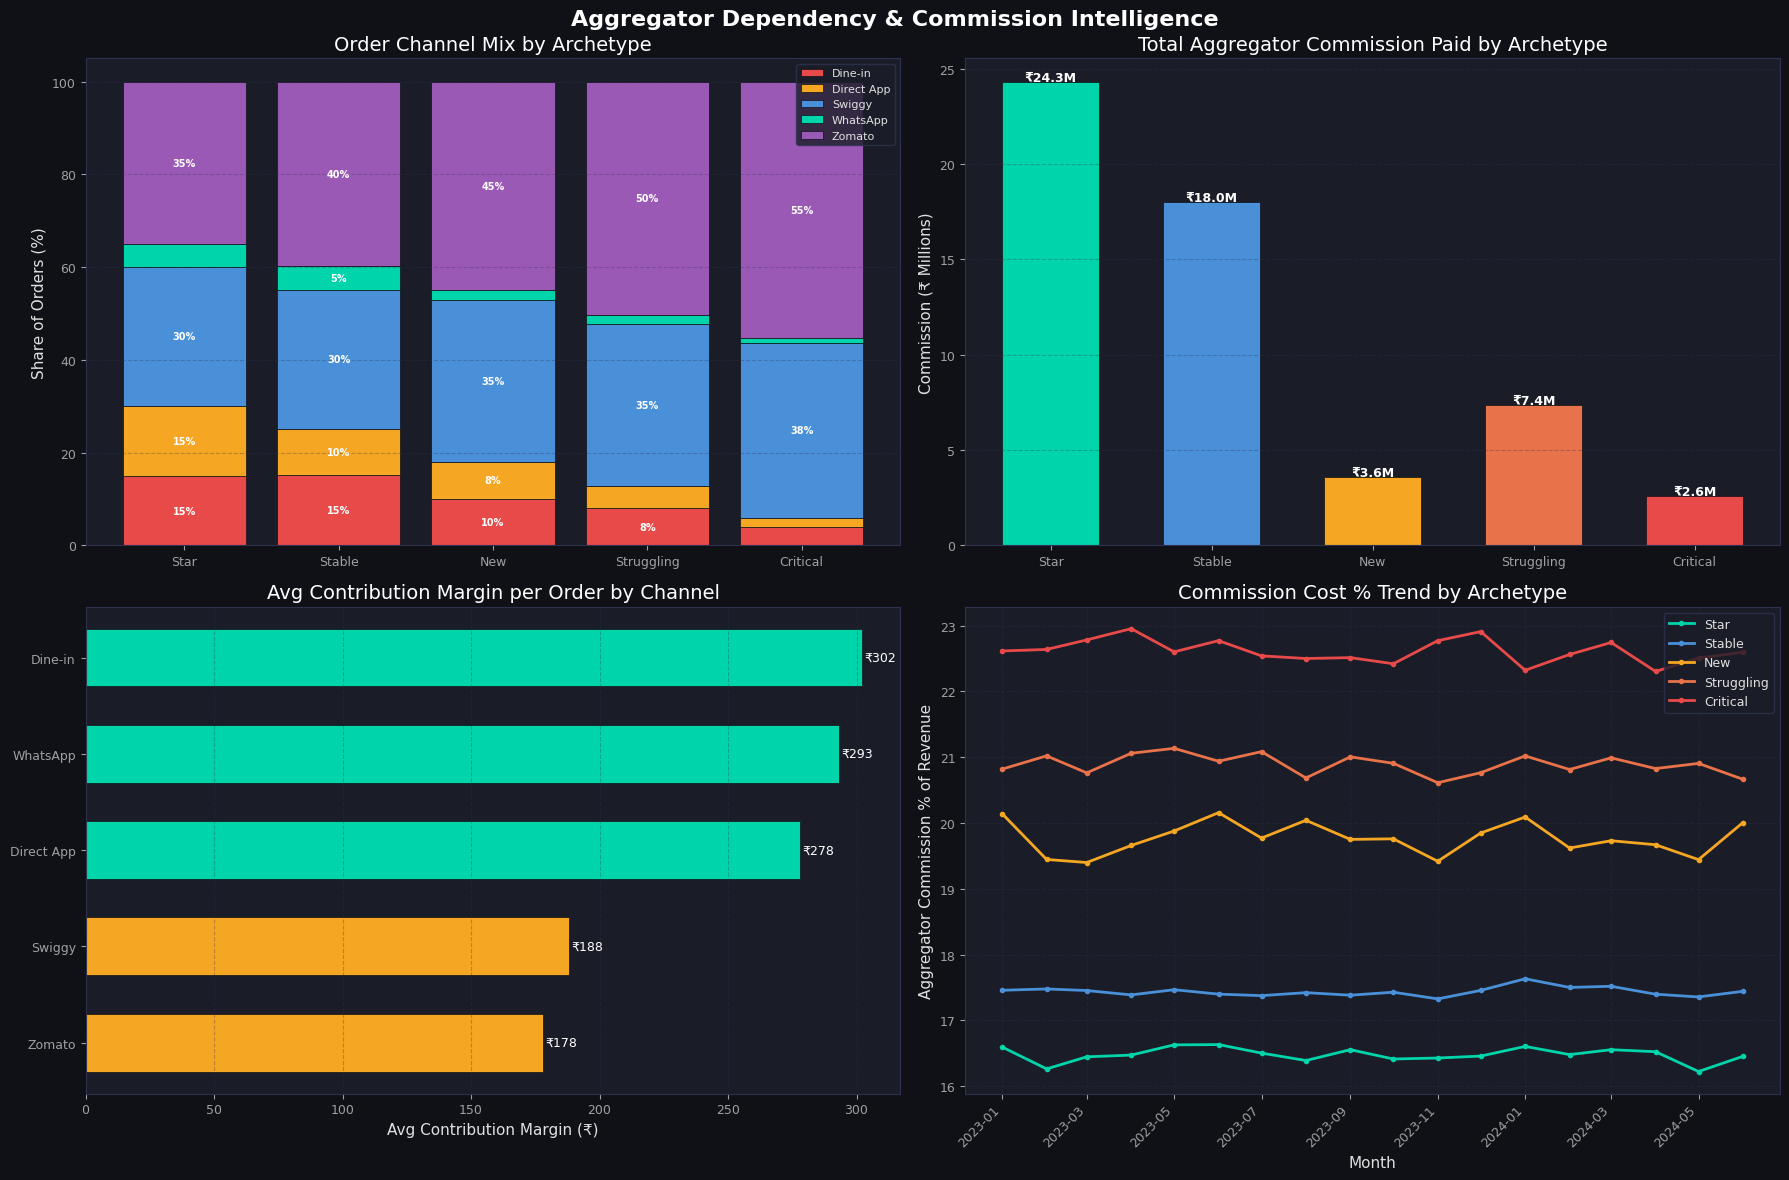

✅ Chart 4 saved


In [10]:
# ============================================================
# CHART 4 — AGGREGATOR DEPENDENCY & COMMISSION ANALYSIS
# ============================================================

# Fix: merge archetype into daily_transactions
dt = daily_transactions.merge(
    outlet_master[['outlet_id', 'archetype']],
    on='outlet_id', how='left'
)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Aggregator Dependency & Commission Intelligence',
             fontsize=16, fontweight='bold', color='white')

# ── Plot 1: Order Channel Mix by Archetype ─────────────────
ax1 = axes[0, 0]
channel_arch = dt.groupby(
    ['archetype', 'order_channel'])['transaction_id'].count().unstack(fill_value=0)
channel_arch     = channel_arch.reindex(archetype_order)
channel_arch_pct = channel_arch.div(channel_arch.sum(axis=1), axis=0) * 100

channel_colors = ['#E84A4A','#F5A623','#4A90D9','#00D4AA','#9B59B6']
bottom = np.zeros(len(channel_arch_pct))
for i, channel in enumerate(channel_arch_pct.columns):
    bars = ax1.bar(channel_arch_pct.index,
                   channel_arch_pct[channel],
                   bottom=bottom,
                   color=channel_colors[i % len(channel_colors)],
                   label=channel, edgecolor='#0F1117', linewidth=0.5)
    for bar, val in zip(bars, channel_arch_pct[channel]):
        if val > 5:
            ax1.text(bar.get_x() + bar.get_width()/2,
                     bar.get_y() + bar.get_height()/2,
                     f'{val:.0f}%', ha='center', va='center',
                     color='white', fontsize=7, fontweight='bold')
    bottom += channel_arch_pct[channel].values

ax1.set_title('Order Channel Mix by Archetype', color='white')
ax1.set_ylabel('Share of Orders (%)')
ax1.set_xticklabels([a.title() for a in channel_arch_pct.index])
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(True, alpha=0.3, axis='y')

# ── Plot 2: Total Commission Paid by Archetype ─────────────
ax2 = axes[0, 1]
commission_data = dt[
    dt['order_channel'].isin(['Zomato', 'Swiggy'])
].groupby('archetype')['aggregator_commission'].sum().reindex(archetype_order)

bars = ax2.bar(commission_data.index,
               commission_data.values / 1e6,
               color=[COLORS[a] for a in commission_data.index],
               edgecolor='#0F1117', linewidth=0.5, width=0.6)
for bar, val in zip(bars, commission_data.values / 1e6):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05,
             f'₹{val:.1f}M', ha='center', color='white',
             fontsize=9, fontweight='bold')
ax2.set_title('Total Aggregator Commission Paid by Archetype', color='white')
ax2.set_ylabel('Commission (₹ Millions)')
ax2.set_xticklabels([a.title() for a in commission_data.index])
ax2.grid(True, alpha=0.3, axis='y')

# ── Plot 3: Contribution Margin by Channel ─────────────────
ax3 = axes[1, 0]
margin_by_channel = dt.groupby('order_channel').agg(
    avg_margin  = ('contribution_margin', 'mean'),
    avg_revenue = ('net_amount', 'mean')
).round(0)
margin_by_channel = margin_by_channel.sort_values('avg_margin', ascending=True)

colors_channel = ['#E84A4A' if m < 150 else '#F5A623'
                  if m < 200 else '#00D4AA'
                  for m in margin_by_channel['avg_margin']]
bars = ax3.barh(margin_by_channel.index,
                margin_by_channel['avg_margin'],
                color=colors_channel,
                edgecolor='#0F1117', linewidth=0.5, height=0.6)
for bar, val in zip(bars, margin_by_channel['avg_margin']):
    ax3.text(val + 1, bar.get_y() + bar.get_height()/2,
             f'₹{val:.0f}', va='center', color='white', fontsize=9)
ax3.set_title('Avg Contribution Margin per Order by Channel', color='white')
ax3.set_xlabel('Avg Contribution Margin (₹)')
ax3.grid(True, alpha=0.3, axis='x')

# ── Plot 4: Commission Cost % Trend Over Time ──────────────
ax4 = axes[1, 1]
commission_trend = monthly_perf.groupby(['month', 'archetype'])[
    'commission_cost_pct'].mean().unstack()
for archetype in archetype_order:
    if archetype in commission_trend.columns:
        ax4.plot(commission_trend.index,
                 commission_trend[archetype],
                 color=COLORS[archetype], linewidth=2,
                 label=archetype.title(), marker='o', markersize=3)
ax4.set_title('Commission Cost % Trend by Archetype', color='white')
ax4.set_ylabel('Aggregator Commission % of Revenue')
ax4.set_xlabel('Month')
ax4.legend(loc='upper right')
ax4.grid(True, alpha=0.3)
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig(f'{CHART_PATH}\\chart_04_aggregator_analysis.png',
            dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()
print("✅ Chart 4 saved")

In [13]:
# ============================================================
# DIAGNOSTIC — Check staff_merged data
# ============================================================

print("staff_df month dtype    :", staff_df['month'].dtype)
print("monthly_perf month dtype:", monthly_perf['month'].dtype)
print()

# Check merge result
print("staff_merged shape:", staff_merged.shape)
print("NaN in revenue    :", staff_merged['revenue'].isna().sum())
print("NaN in archetype  :", staff_merged['archetype'].isna().sum())
print()

print("Sample staff_merged:")
print(staff_merged[['outlet_id','month','turnover_pct',
                     'revenue','avg_rating','archetype']].head(10))
print()

print("Revenue stats:")
print(staff_merged['revenue'].describe())
print()

print("Training hours stats:")
print(staff_merged['training_hours'].describe())

staff_df month dtype    : object
monthly_perf month dtype: object

staff_merged shape: (1530, 16)
NaN in revenue    : 1530
NaN in archetype  : 1530

Sample staff_merged:
  outlet_id      month  turnover_pct  revenue  avg_rating archetype
0     OT001 2023-01-01           8.5      NaN         NaN       NaN
1     OT001 2023-02-01          11.9      NaN         NaN       NaN
2     OT001 2023-03-01          10.3      NaN         NaN       NaN
3     OT001 2023-04-01           5.8      NaN         NaN       NaN
4     OT001 2023-05-01          13.7      NaN         NaN       NaN
5     OT001 2023-06-01           6.6      NaN         NaN       NaN
6     OT001 2023-07-01           9.3      NaN         NaN       NaN
7     OT001 2023-08-01           9.5      NaN         NaN       NaN
8     OT001 2023-09-01          14.6      NaN         NaN       NaN
9     OT001 2023-10-01           6.1      NaN         NaN       NaN

Revenue stats:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
5

In [14]:
# ============================================================
# FIX — Standardize month format before merge
# ============================================================

# Convert both to YYYY-MM string format
staff_df['month']     = pd.to_datetime(staff_df['month']).dt.strftime('%Y-%m')
monthly_perf['month'] = pd.to_datetime(monthly_perf['month']).dt.strftime('%Y-%m')

# Verify formats match
print("staff_df month sample    :", staff_df['month'].head(3).tolist())
print("monthly_perf month sample:", monthly_perf['month'].head(3).tolist())

# Redo the merge
staff_merged = staff_df.merge(
    monthly_perf[['outlet_id', 'month', 'revenue',
                  'avg_rating', 'net_margin_pct',
                  'complaint_rate', 'archetype']],
    on=['outlet_id', 'month'], how='left'
)
staff_merged['month'] = pd.to_datetime(staff_merged['month'])

# Verify
print(f"\nstaff_merged shape     : {staff_merged.shape}")
print(f"NaN in revenue         : {staff_merged['revenue'].isna().sum()}")
print(f"NaN in archetype       : {staff_merged['archetype'].isna().sum()}")
print(f"\nRevenue sample:")
print(staff_merged['revenue'].describe().round(0))

staff_df month sample    : ['2023-01', '2023-02', '2023-03']
monthly_perf month sample: ['2023-01', '2023-02', '2023-03']

staff_merged shape     : (1530, 16)
NaN in revenue         : 0
NaN in archetype       : 0

Revenue sample:
count      1530.0
mean     214884.0
std      121705.0
min       25389.0
25%      108748.0
50%      188608.0
75%      297118.0
max      553308.0
Name: revenue, dtype: float64


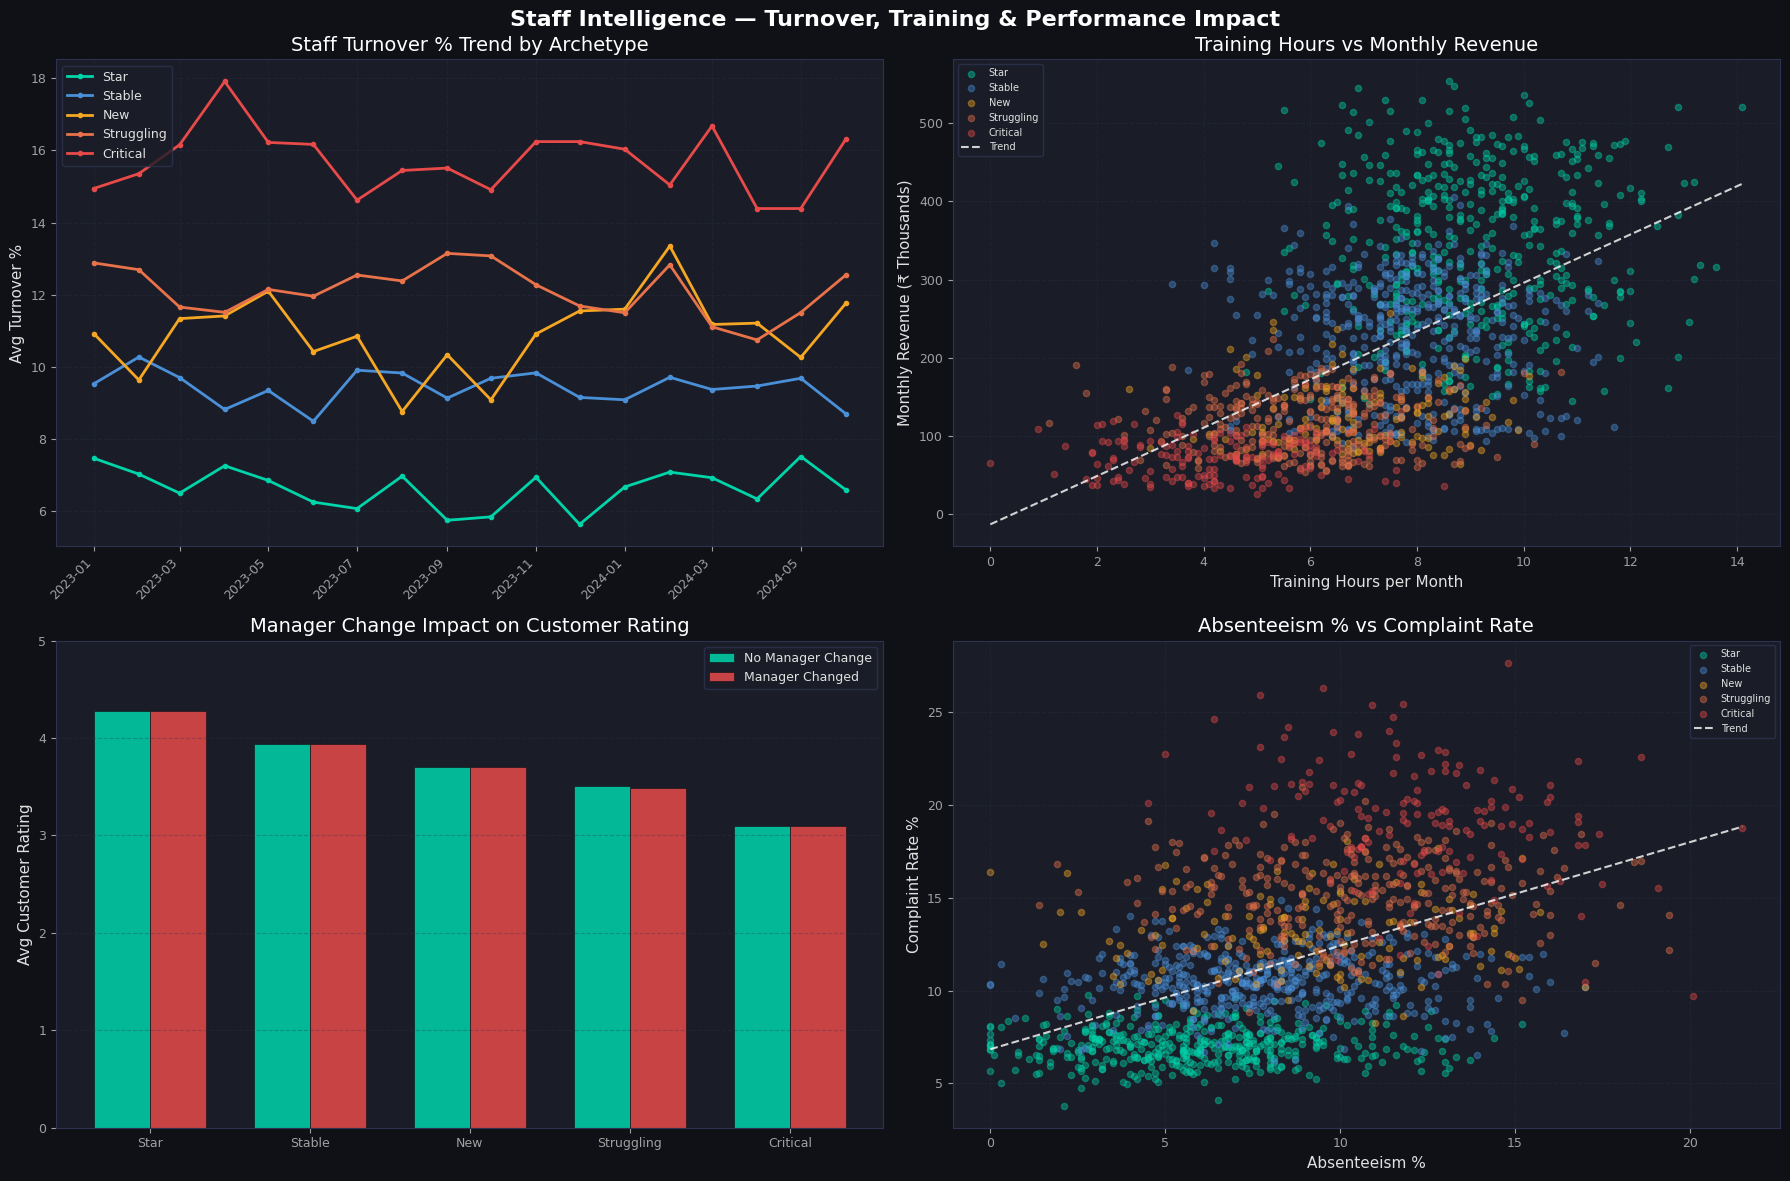

✅ Chart 5 saved


In [15]:
# ============================================================
# CHART 5 — STAFF INTELLIGENCE ANALYSIS (FIXED)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Staff Intelligence — Turnover, Training & Performance Impact',
             fontsize=16, fontweight='bold', color='white')

# ── Plot 1: Turnover % by Archetype Over Time ──────────────
ax1 = axes[0, 0]
turnover_trend = staff_merged.groupby(
    ['month', 'archetype'])['turnover_pct'].mean().unstack()
for archetype in archetype_order:
    if archetype in turnover_trend.columns:
        ax1.plot(turnover_trend.index,
                 turnover_trend[archetype],
                 color=COLORS[archetype], linewidth=2,
                 label=archetype.title(), marker='o', markersize=3)
ax1.set_title('Staff Turnover % Trend by Archetype', color='white')
ax1.set_ylabel('Avg Turnover %')
ax1.legend()
ax1.grid(True, alpha=0.3)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# ── Plot 2: Training Hours vs Revenue Scatter ──────────────
ax2 = axes[0, 1]
for archetype in archetype_order:
    data = staff_merged[staff_merged['archetype'] == archetype]
    ax2.scatter(data['training_hours'],
                data['revenue'] / 1000,
                color=COLORS[archetype], alpha=0.4,
                s=20, label=archetype.title())

from numpy.polynomial.polynomial import polyfit
x      = staff_merged['training_hours'].dropna()
y      = staff_merged.loc[x.index, 'revenue'] / 1000
coeffs = polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
ax2.plot(x_line, coeffs[0] + coeffs[1] * x_line,
         color='white', linewidth=1.5,
         linestyle='--', label='Trend', alpha=0.8)
ax2.set_title('Training Hours vs Monthly Revenue', color='white')
ax2.set_xlabel('Training Hours per Month')
ax2.set_ylabel('Monthly Revenue (₹ Thousands)')
ax2.legend(fontsize=7)
ax2.grid(True, alpha=0.3)

# ── Plot 3: Manager Changes Impact on Rating ───────────────
ax3 = axes[1, 0]
manager_impact = staff_merged.groupby(
    ['archetype', 'manager_change'])[['avg_rating', 'net_margin_pct']].mean()
manager_impact = manager_impact.reset_index()

x     = np.arange(len(archetype_order))
width = 0.35
for i, change in enumerate([0, 1]):
    data  = manager_impact[manager_impact['manager_change'] == change]
    data  = data.set_index('archetype').reindex(archetype_order)
    label = 'No Manager Change' if change == 0 else 'Manager Changed'
    color = '#00D4AA' if change == 0 else '#E84A4A'
    ax3.bar(x + i * width, data['avg_rating'],
            width=width, label=label,
            color=color, alpha=0.85,
            edgecolor='#0F1117', linewidth=0.5)

ax3.set_title('Manager Change Impact on Customer Rating', color='white')
ax3.set_ylabel('Avg Customer Rating')
ax3.set_xticks(x + width / 2)
ax3.set_xticklabels([a.title() for a in archetype_order])
ax3.legend()
ax3.set_ylim(0, 5)
ax3.grid(True, alpha=0.3, axis='y')

# ── Plot 4: Absenteeism vs Complaint Rate ──────────────────
ax4 = axes[1, 1]
for archetype in archetype_order:
    data = staff_merged[staff_merged['archetype'] == archetype]
    ax4.scatter(data['absenteeism_pct'],
                data['complaint_rate'],
                color=COLORS[archetype], alpha=0.4,
                s=20, label=archetype.title())

x2      = staff_merged['absenteeism_pct'].dropna()
y2      = staff_merged.loc[x2.index, 'complaint_rate']
coeffs2 = polyfit(x2, y2, 1)
x_line2 = np.linspace(x2.min(), x2.max(), 100)
ax4.plot(x_line2, coeffs2[0] + coeffs2[1] * x_line2,
         color='white', linewidth=1.5,
         linestyle='--', label='Trend', alpha=0.8)
ax4.set_title('Absenteeism % vs Complaint Rate', color='white')
ax4.set_xlabel('Absenteeism %')
ax4.set_ylabel('Complaint Rate %')
ax4.legend(fontsize=7)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{CHART_PATH}\\chart_05_staff_intelligence.png',
            dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()
print("✅ Chart 5 saved")

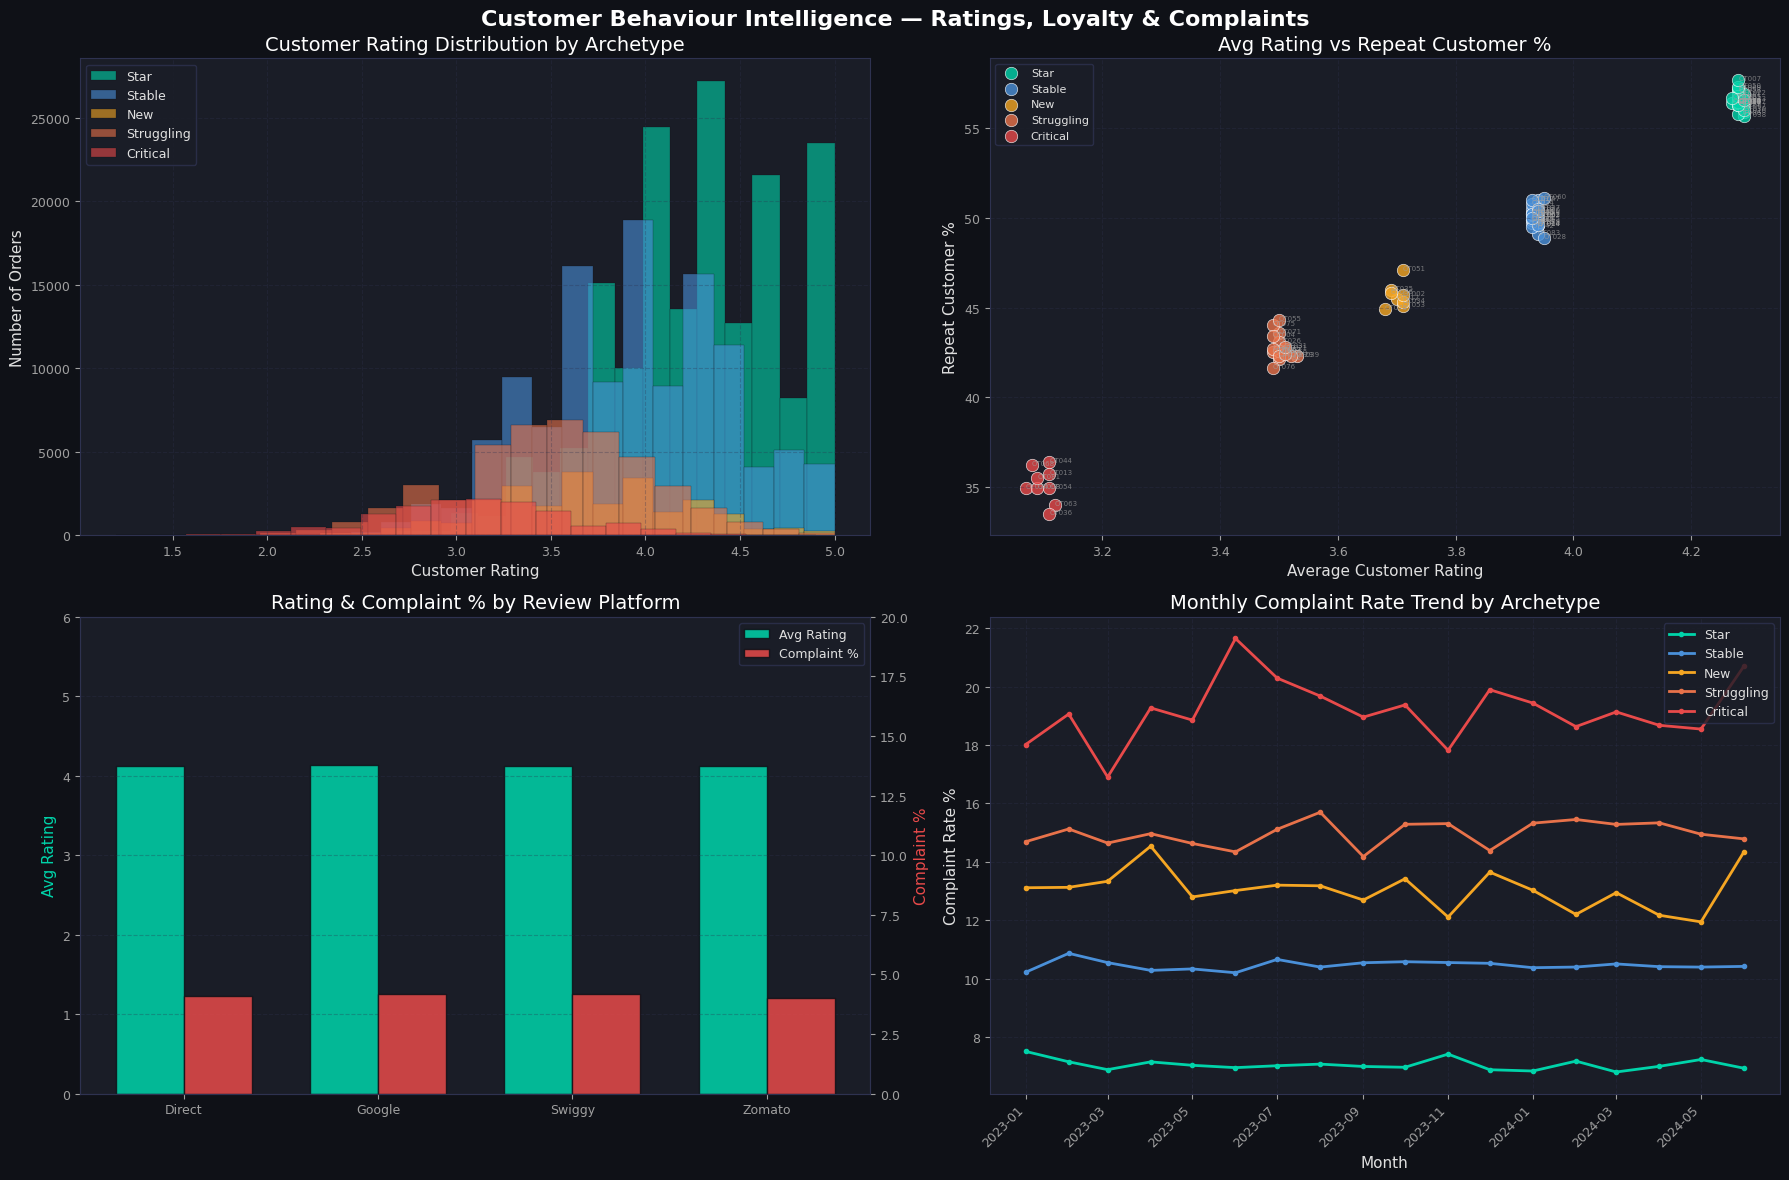

✅ Chart 6 saved


In [16]:
# ============================================================
# CHART 6 — CUSTOMER BEHAVIOUR ANALYSIS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Customer Behaviour Intelligence — Ratings, Loyalty & Complaints',
             fontsize=16, fontweight='bold', color='white')

# Fix: merge archetype into daily_transactions (reuse dt from Chart 4)
# dt already has archetype merged

# ── Plot 1: Rating Distribution by Archetype ──────────────
ax1 = axes[0, 0]
for archetype in archetype_order:
    data = dt[
        (dt['archetype'] == archetype) &
        (dt['customer_rating'].notna())
    ]['customer_rating']
    ax1.hist(data, bins=20, alpha=0.6,
             color=COLORS[archetype],
             label=archetype.title(),
             edgecolor='#0F1117', linewidth=0.3)
ax1.set_title('Customer Rating Distribution by Archetype', color='white')
ax1.set_xlabel('Customer Rating')
ax1.set_ylabel('Number of Orders')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── Plot 2: Repeat Customer % vs Avg Rating Scatter ────────
ax2 = axes[0, 1]
for archetype in archetype_order:
    data = outlet_scores[outlet_scores['archetype'] == archetype]
    ax2.scatter(
        data['avg_rating'],
        data['avg_repeat_pct'],
        color=COLORS[archetype], s=80,
        alpha=0.8, label=archetype.title(),
        edgecolors='white', linewidth=0.5
    )
    for _, row in data.iterrows():
        ax2.annotate(row['outlet_id'],
                     (row['avg_rating'], row['avg_repeat_pct']),
                     fontsize=5, color='#A0A0A0', alpha=0.7)
ax2.set_title('Avg Rating vs Repeat Customer %', color='white')
ax2.set_xlabel('Average Customer Rating')
ax2.set_ylabel('Repeat Customer %')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# ── Plot 3: Review Platform Rating & Complaint % ──────────
ax3 = axes[1, 0]
platform_sentiment = reviews_df.groupby('platform').agg(
    avg_rating       = ('rating',         'mean'),
    total_reviews    = ('review_id',      'count'),
    total_complaints = ('is_complaint',   'sum')
).round(2)
platform_sentiment['complaint_pct'] = (
    platform_sentiment['total_complaints'] /
    platform_sentiment['total_reviews'] * 100
).round(1)

x     = np.arange(len(platform_sentiment))
width = 0.35
bars1 = ax3.bar(x - width/2,
                platform_sentiment['avg_rating'],
                width=width, label='Avg Rating',
                color='#00D4AA', alpha=0.85,
                edgecolor='#0F1117')
ax3b  = ax3.twinx()
ax3b.set_facecolor('#1A1D27')
bars2 = ax3b.bar(x + width/2,
                 platform_sentiment['complaint_pct'],
                 width=width, label='Complaint %',
                 color='#E84A4A', alpha=0.85,
                 edgecolor='#0F1117')
ax3.set_title('Rating & Complaint % by Review Platform', color='white')
ax3.set_ylabel('Avg Rating', color='#00D4AA')
ax3b.set_ylabel('Complaint %', color='#E84A4A')
ax3.set_xticks(x)
ax3.set_xticklabels(platform_sentiment.index)
ax3.set_ylim(0, 6)
ax3b.set_ylim(0, 20)
ax3b.tick_params(colors='#A0A0A0')
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3b.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
ax3.grid(True, alpha=0.3, axis='y')

# ── Plot 4: Monthly Complaint Rate Trend ──────────────────
ax4 = axes[1, 1]
monthly_perf['month_dt'] = pd.to_datetime(monthly_perf['month'])
complaint_trend = monthly_perf.groupby(
    ['month_dt', 'archetype'])['complaint_rate'].mean().unstack()
for archetype in archetype_order:
    if archetype in complaint_trend.columns:
        ax4.plot(complaint_trend.index,
                 complaint_trend[archetype],
                 color=COLORS[archetype], linewidth=2,
                 label=archetype.title(),
                 marker='o', markersize=3)
ax4.set_title('Monthly Complaint Rate Trend by Archetype', color='white')
ax4.set_ylabel('Complaint Rate %')
ax4.set_xlabel('Month')
ax4.legend()
ax4.grid(True, alpha=0.3)
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig(f'{CHART_PATH}\\chart_06_customer_behaviour.png',
            dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()
print("✅ Chart 6 saved")

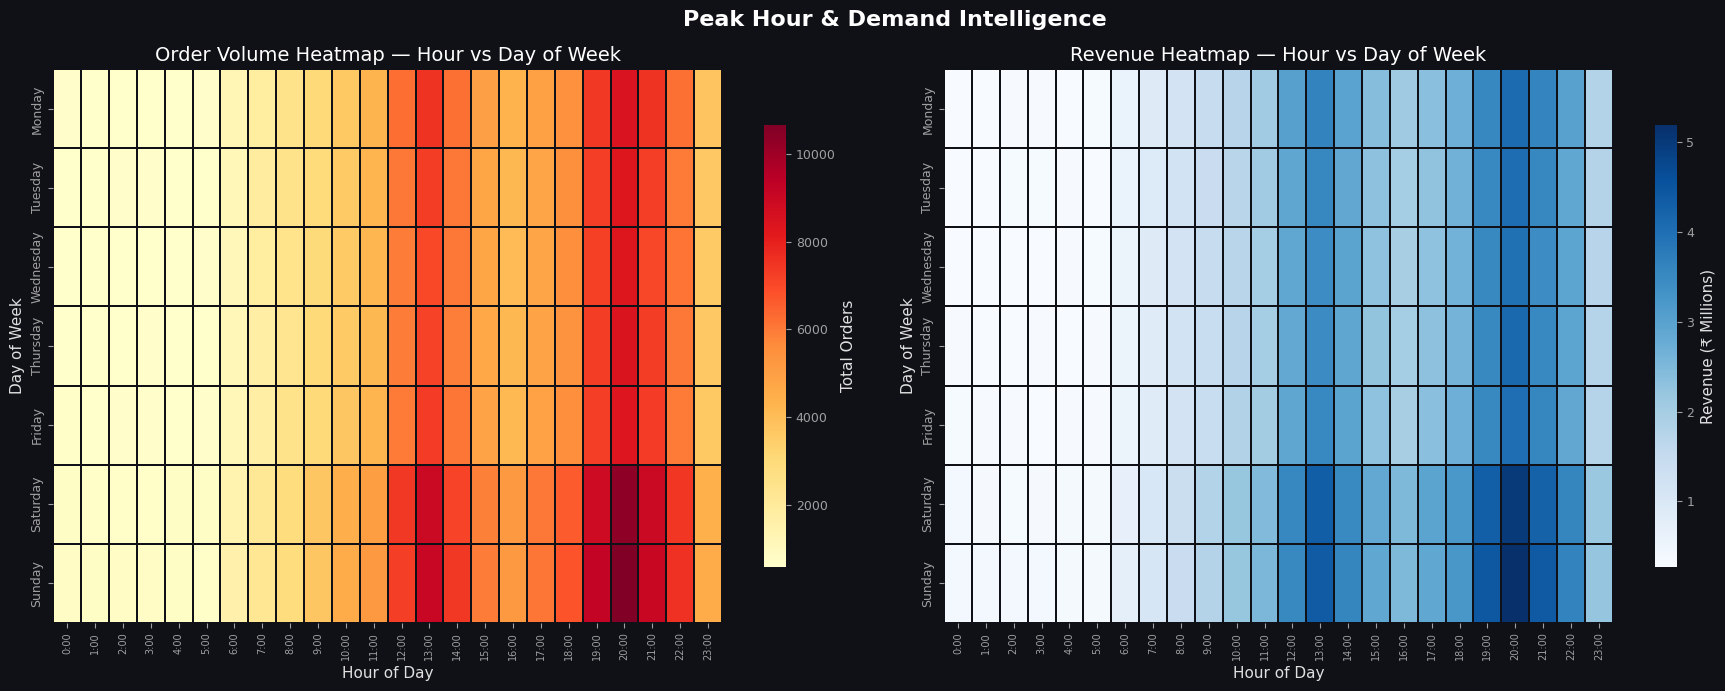

✅ Chart 7 saved


In [17]:
# ============================================================
# CHART 7 — PEAK HOUR & DEMAND HEATMAP
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Peak Hour & Demand Intelligence',
             fontsize=16, fontweight='bold', color='white')

# Extract hour from transaction_time
dt['hour'] = pd.to_datetime(
    dt['transaction_time'], format='%H:%M:%S'
).dt.hour

# ── Plot 1: Orders Heatmap — Hour vs Day of Week ───────────
ax1 = axes[0]
day_order   = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot_orders = dt.groupby(['day_of_week','hour'])['transaction_id'].count().unstack(fill_value=0)
pivot_orders = pivot_orders.reindex(day_order)

sns.heatmap(
    pivot_orders,
    ax=ax1,
    cmap='YlOrRd',
    linewidths=0.3,
    linecolor='#0F1117',
    fmt='.0f',
    cbar_kws={'label': 'Total Orders', 'shrink': 0.8}
)
ax1.set_title('Order Volume Heatmap — Hour vs Day of Week', color='white')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Day of Week')
ax1.set_xticklabels([f'{h}:00' for h in range(24)], rotation=90, fontsize=7)

# ── Plot 2: Revenue Heatmap — Hour vs Day of Week ─────────
ax2 = axes[1]
pivot_revenue = dt.groupby(['day_of_week','hour'])['net_amount'].sum().unstack(fill_value=0)
pivot_revenue = pivot_revenue.reindex(day_order) / 1e6

sns.heatmap(
    pivot_revenue,
    ax=ax2,
    cmap='Blues',
    linewidths=0.3,
    linecolor='#0F1117',
    fmt='.1f',
    cbar_kws={'label': 'Revenue (₹ Millions)', 'shrink': 0.8}
)
ax2.set_title('Revenue Heatmap — Hour vs Day of Week', color='white')
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Day of Week')
ax2.set_xticklabels([f'{h}:00' for h in range(24)], rotation=90, fontsize=7)

plt.tight_layout()
plt.savefig(f'{CHART_PATH}\\chart_07_peak_hour_heatmap.png',
            dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()
print("✅ Chart 7 saved")

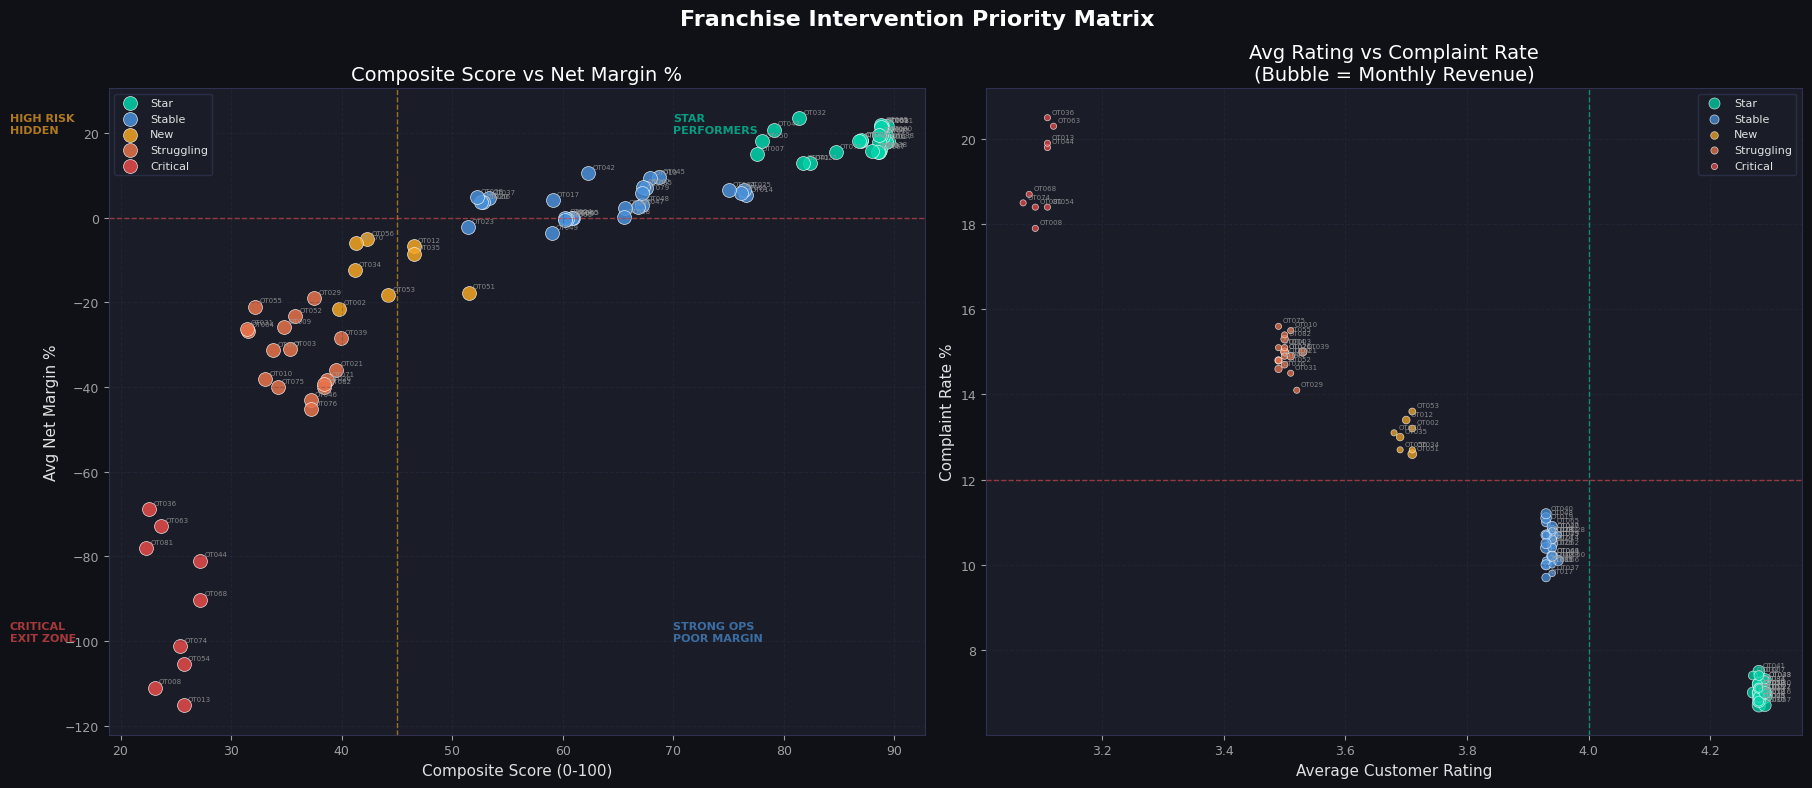

✅ Chart 8 saved


In [18]:
# ============================================================
# CHART 8 — INTERVENTION PRIORITY MATRIX SCATTER
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Franchise Intervention Priority Matrix',
             fontsize=16, fontweight='bold', color='white')

# ── Plot 1: Composite Score vs Net Margin ─────────────────
ax1 = axes[0]
for archetype in archetype_order:
    data = outlet_scores[outlet_scores['archetype'] == archetype]
    ax1.scatter(
        data['composite_score'],
        data['avg_net_margin_pct'],
        color=COLORS[archetype], s=100,
        alpha=0.85, label=archetype.title(),
        edgecolors='white', linewidth=0.5
    )
    for _, row in data.iterrows():
        ax1.annotate(
            row['outlet_id'],
            (row['composite_score'], row['avg_net_margin_pct']),
            fontsize=5, color='#A0A0A0', alpha=0.8,
            xytext=(3, 3), textcoords='offset points'
        )

# Quadrant lines
ax1.axvline(x=45, color='#F5A623', linestyle='--',
            linewidth=1, alpha=0.6)
ax1.axhline(y=0,  color='#E84A4A', linestyle='--',
            linewidth=1, alpha=0.6)

# Quadrant labels
ax1.text(70, 20,  'STAR\nPERFORMERS',
         color='#00D4AA', fontsize=8, alpha=0.7, fontweight='bold')
ax1.text(10, 20,  'HIGH RISK\nHIDDEN',
         color='#F5A623', fontsize=8, alpha=0.7, fontweight='bold')
ax1.text(70, -100,'STRONG OPS\nPOOR MARGIN',
         color='#4A90D9', fontsize=8, alpha=0.7, fontweight='bold')
ax1.text(10, -100,'CRITICAL\nEXIT ZONE',
         color='#E84A4A', fontsize=8, alpha=0.7, fontweight='bold')

ax1.set_title('Composite Score vs Net Margin %', color='white')
ax1.set_xlabel('Composite Score (0-100)')
ax1.set_ylabel('Avg Net Margin %')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# ── Plot 2: Rating vs Complaint Rate Bubble ───────────────
ax2 = axes[1]
for archetype in archetype_order:
    data = outlet_scores[outlet_scores['archetype'] == archetype]
    bubble_size = (data['avg_monthly_revenue'] / 5000).clip(20, 300)
    ax2.scatter(
        data['avg_rating'],
        data['avg_complaint_rate'],
        color=COLORS[archetype], s=bubble_size,
        alpha=0.75, label=archetype.title(),
        edgecolors='white', linewidth=0.5
    )
    for _, row in data.iterrows():
        ax2.annotate(
            row['outlet_id'],
            (row['avg_rating'], row['avg_complaint_rate']),
            fontsize=5, color='#A0A0A0', alpha=0.8,
            xytext=(3, 3), textcoords='offset points'
        )

ax2.axvline(x=4.0, color='#00D4AA', linestyle='--',
            linewidth=1, alpha=0.6)
ax2.axhline(y=12,  color='#E84A4A', linestyle='--',
            linewidth=1, alpha=0.6)
ax2.set_title('Avg Rating vs Complaint Rate\n(Bubble = Monthly Revenue)',
              color='white')
ax2.set_xlabel('Average Customer Rating')
ax2.set_ylabel('Complaint Rate %')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{CHART_PATH}\\chart_08_intervention_matrix.png',
            dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()
print("✅ Chart 8 saved")

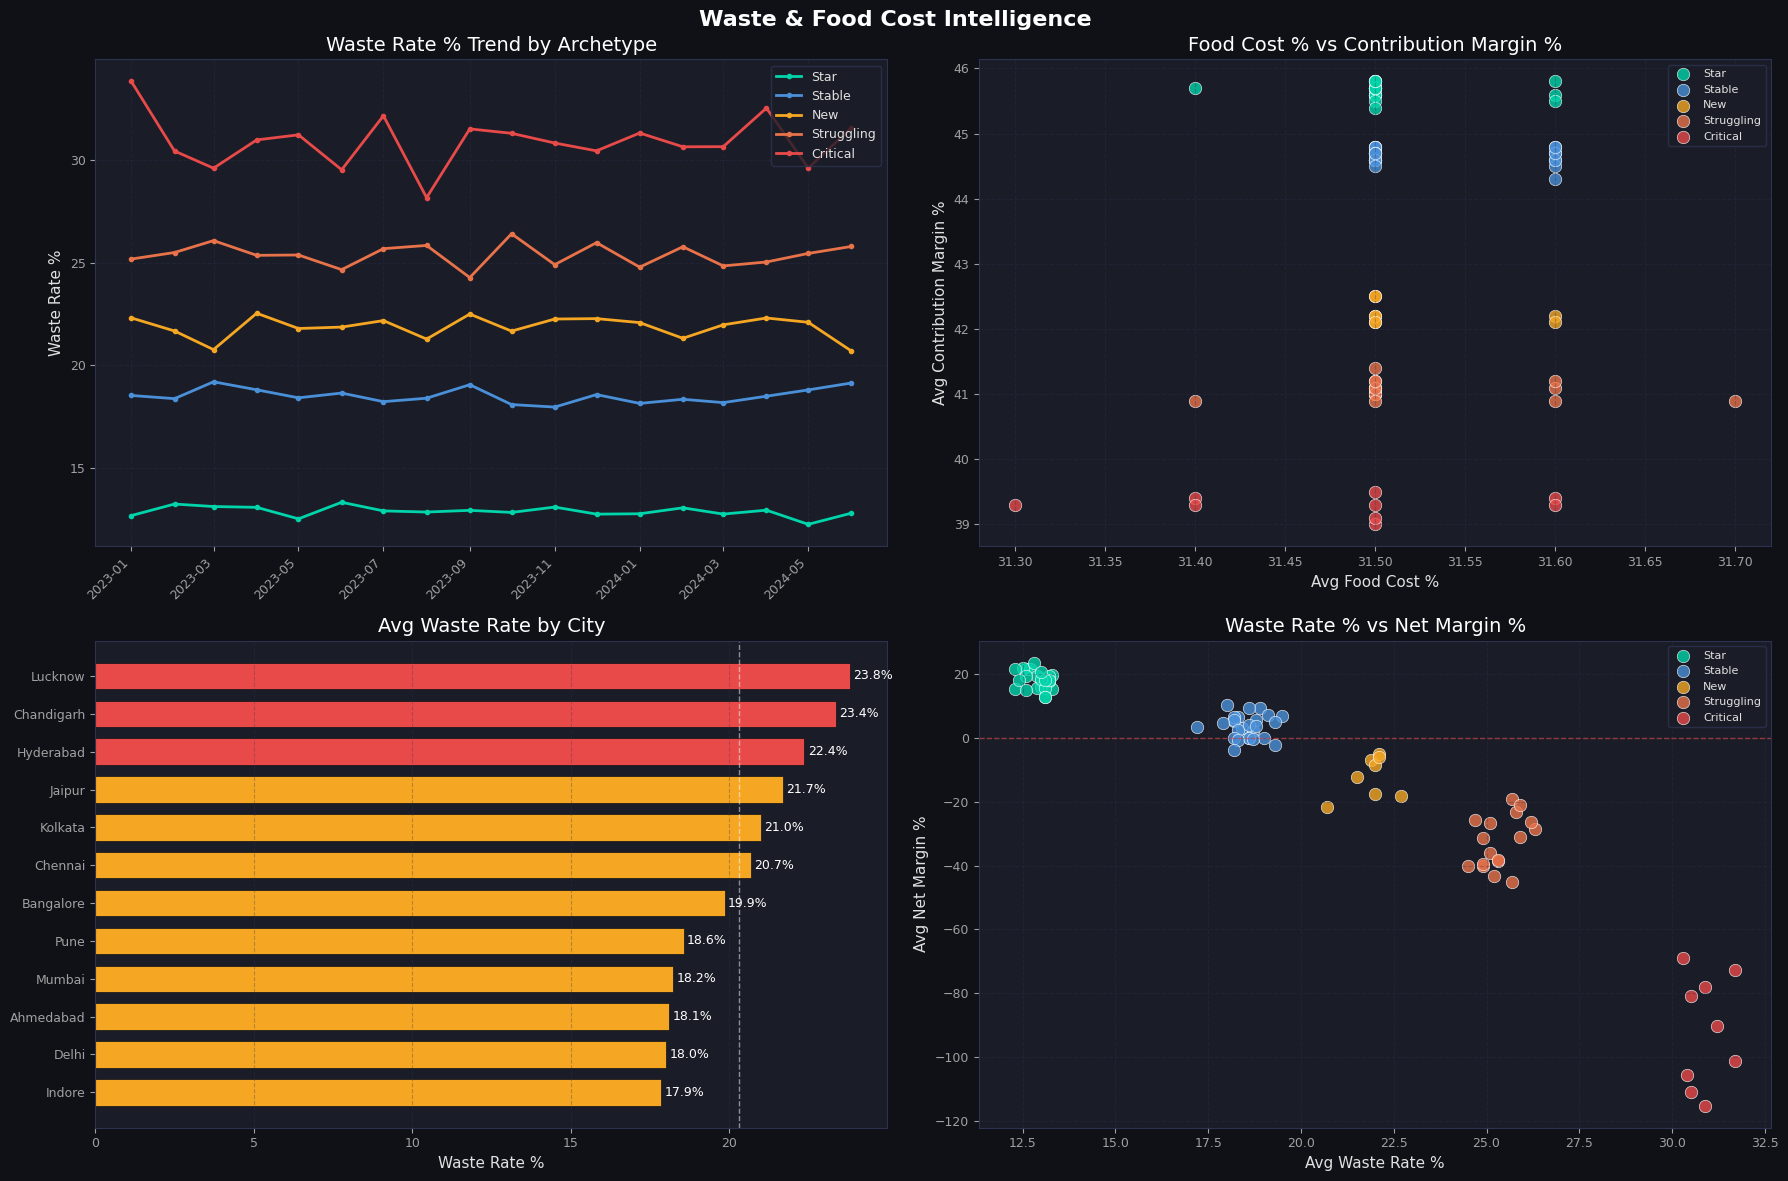

✅ Chart 9 saved


In [19]:
# ============================================================
# CHART 9 — WASTE & FOOD COST INTELLIGENCE
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Waste & Food Cost Intelligence',
             fontsize=16, fontweight='bold', color='white')

# ── Plot 1: Waste Rate by Archetype Over Time ──────────────
ax1 = axes[0, 0]
waste_trend = monthly_perf.groupby(
    ['month_dt', 'archetype'])['waste_rate'].mean().unstack()
for archetype in archetype_order:
    if archetype in waste_trend.columns:
        ax1.plot(waste_trend.index,
                 waste_trend[archetype],
                 color=COLORS[archetype], linewidth=2,
                 label=archetype.title(),
                 marker='o', markersize=3)
ax1.set_title('Waste Rate % Trend by Archetype', color='white')
ax1.set_ylabel('Waste Rate %')
ax1.legend()
ax1.grid(True, alpha=0.3)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# ── Plot 2: Food Cost % vs Contribution Margin % ──────────
ax2 = axes[0, 1]
for archetype in archetype_order:
    data = outlet_scores[outlet_scores['archetype'] == archetype]
    ax2.scatter(
        data['avg_food_cost_pct'],
        data['avg_contribution_pct'],
        color=COLORS[archetype], s=80,
        alpha=0.8, label=archetype.title(),
        edgecolors='white', linewidth=0.5
    )
ax2.set_title('Food Cost % vs Contribution Margin %', color='white')
ax2.set_xlabel('Avg Food Cost %')
ax2.set_ylabel('Avg Contribution Margin %')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# ── Plot 3: Waste Rate by City ─────────────────────────────
ax3 = axes[1, 0]
city_waste = monthly_perf.groupby('city')['waste_rate'].mean().sort_values(ascending=True)
colors_waste = ['#00D4AA' if v < 15 else '#F5A623'
                if v < 22 else '#E84A4A'
                for v in city_waste.values]
bars = ax3.barh(city_waste.index, city_waste.values,
                color=colors_waste,
                edgecolor='#0F1117', linewidth=0.5, height=0.7)
for bar, val in zip(bars, city_waste.values):
    ax3.text(val + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', color='white', fontsize=9)
ax3.axvline(x=city_waste.mean(), color='white',
            linestyle='--', linewidth=1, alpha=0.5)
ax3.set_title('Avg Waste Rate by City', color='white')
ax3.set_xlabel('Waste Rate %')
ax3.grid(True, alpha=0.3, axis='x')

# ── Plot 4: Waste Rate vs Net Margin Scatter ───────────────
ax4 = axes[1, 1]
for archetype in archetype_order:
    data = outlet_scores[outlet_scores['archetype'] == archetype]
    ax4.scatter(
        data['avg_waste_rate'],
        data['avg_net_margin_pct'],
        color=COLORS[archetype], s=80,
        alpha=0.8, label=archetype.title(),
        edgecolors='white', linewidth=0.5
    )
ax4.axhline(y=0, color='#E84A4A', linestyle='--',
            linewidth=1, alpha=0.6)
ax4.set_title('Waste Rate % vs Net Margin %', color='white')
ax4.set_xlabel('Avg Waste Rate %')
ax4.set_ylabel('Avg Net Margin %')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{CHART_PATH}\\chart_09_waste_intelligence.png',
            dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()
print("✅ Chart 9 saved")

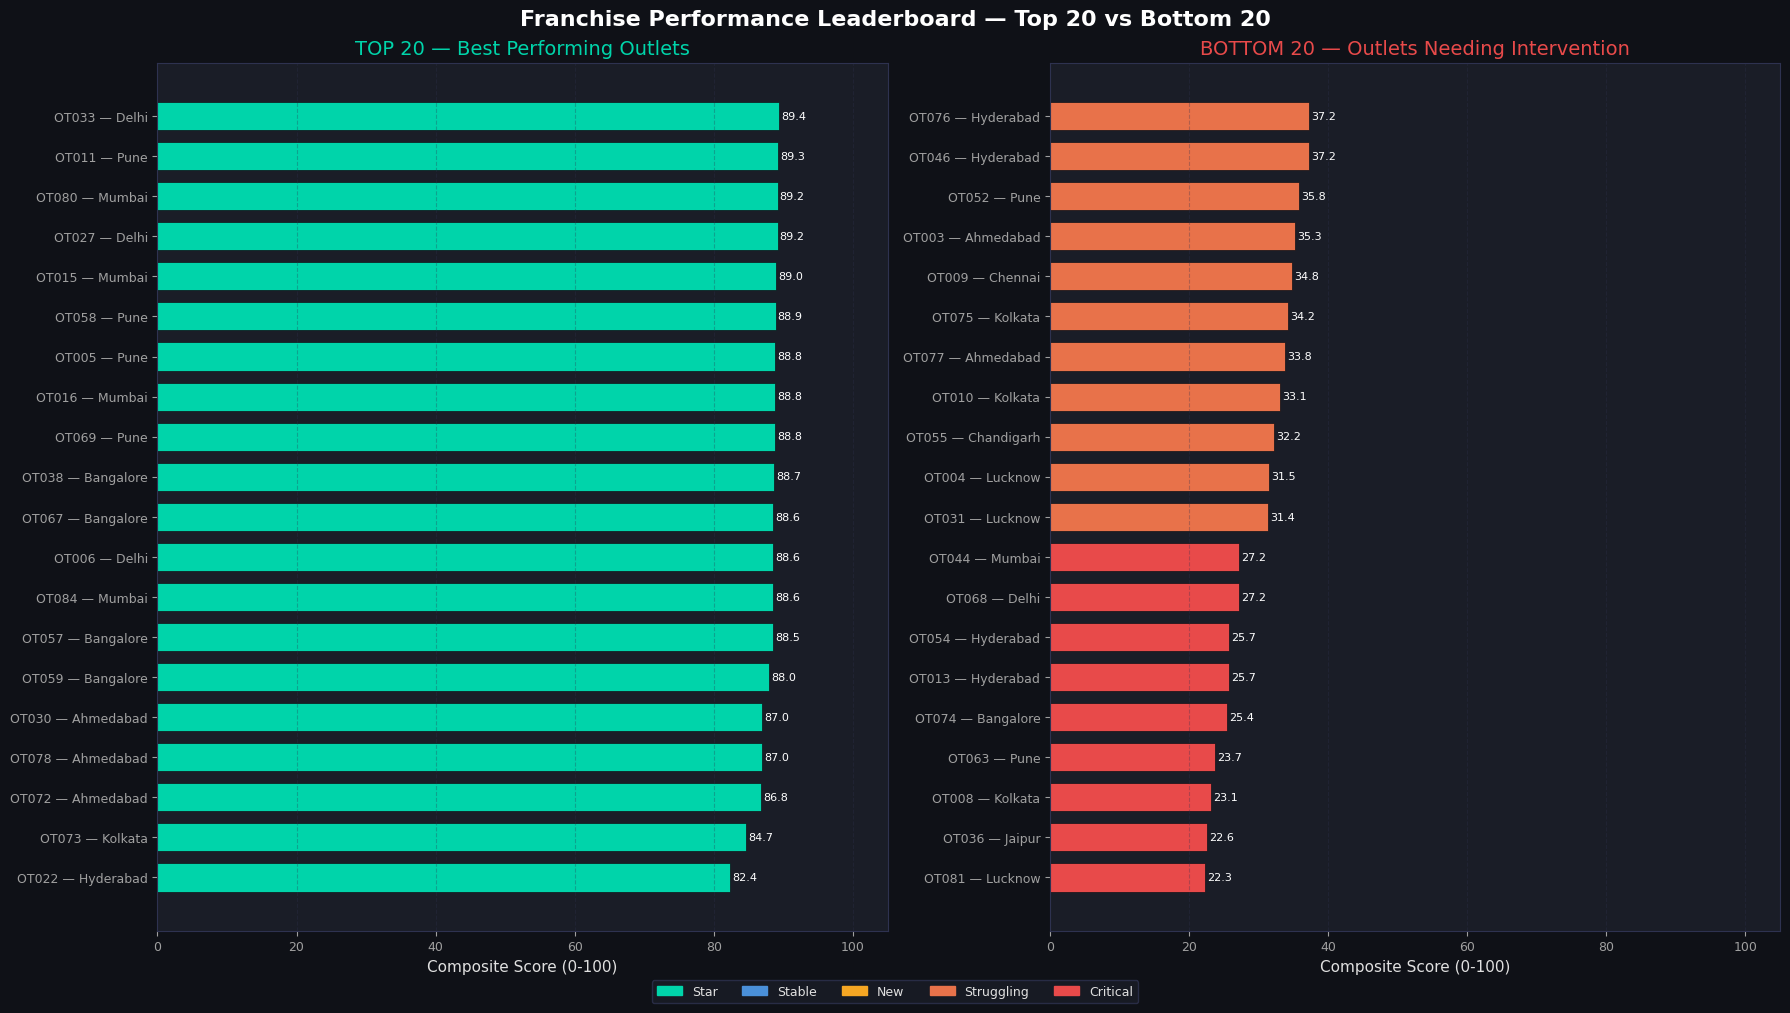

✅ Chart 10 saved

✅ ALL 10 CHARTS COMPLETE — EDA Phase Done


In [20]:
# ============================================================
# CHART 10 — COMPOSITE SCORE LEADERBOARD
# Top 20 & Bottom 20 Outlets
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 10))
fig.suptitle('Franchise Performance Leaderboard — Top 20 vs Bottom 20',
             fontsize=16, fontweight='bold', color='white')

scores_sorted = outlet_scores.sort_values('composite_score', ascending=False)
top20    = scores_sorted.head(20)
bottom20 = scores_sorted.tail(20).sort_values('composite_score', ascending=True)

# ── Plot 1: Top 20 Outlets ─────────────────────────────────
ax1 = axes[0]
colors_top = [COLORS[a] for a in top20['archetype']]
bars = ax1.barh(
    top20['outlet_id'] + ' — ' + top20['city'],
    top20['composite_score'],
    color=colors_top,
    edgecolor='#0F1117', linewidth=0.5, height=0.7
)
for bar, val in zip(bars, top20['composite_score']):
    ax1.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}', va='center', color='white', fontsize=8)
ax1.set_title('TOP 20 — Best Performing Outlets', color='#00D4AA')
ax1.set_xlabel('Composite Score (0-100)')
ax1.set_xlim(0, 105)
ax1.grid(True, alpha=0.3, axis='x')
ax1.invert_yaxis()

# ── Plot 2: Bottom 20 Outlets ──────────────────────────────
ax2 = axes[1]
colors_bot = [COLORS[a] for a in bottom20['archetype']]
bars = ax2.barh(
    bottom20['outlet_id'] + ' — ' + bottom20['city'],
    bottom20['composite_score'],
    color=colors_bot,
    edgecolor='#0F1117', linewidth=0.5, height=0.7
)
for bar, val in zip(bars, bottom20['composite_score']):
    ax2.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}', va='center', color='white', fontsize=8)
ax2.set_title('BOTTOM 20 — Outlets Needing Intervention',
              color='#E84A4A')
ax2.set_xlabel('Composite Score (0-100)')
ax2.set_xlim(0, 105)
ax2.grid(True, alpha=0.3, axis='x')

# Legend
legend_patches = [
    mpatches.Patch(color=COLORS[a], label=a.title())
    for a in archetype_order
]
fig.legend(handles=legend_patches, loc='lower center',
           ncol=5, bbox_to_anchor=(0.5, -0.02),
           facecolor='#1A1D27', edgecolor='#2E3250')

plt.tight_layout()
plt.savefig(f'{CHART_PATH}\\chart_10_leaderboard.png',
            dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()
print("✅ Chart 10 saved")
print("\n✅ ALL 10 CHARTS COMPLETE — EDA Phase Done")